# Model Training and Evaluation

This notebook contains model training and evaluation steps.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import precision_recall_curve, auc, f1_score, confusion_matrix, classification_report

# Paths setup
PROCESSED_DATA_DIR = "../data/processed/"
MODELS_DIR = "../models/"
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
print("Modeling pipeline environment ready.")

Modeling pipeline environment ready.


In [3]:
def compute_auc_pr(y_true, y_probs):
    """Calculates the Area Under the Precision-Recall Curve (AUC-PR)."""
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    return auc(recall, precision)

def evaluate_model_performance(model, X_train, y_train, X_test, y_test, dataset_name, model_name):
    """Trains, cross-validates, and evaluates model architectures on imbalanced splits."""
    print(f"\n=================== {model_name} on {dataset_name} ===================")
    
    # 1. Stratified 5-Fold Cross-Validation on the Training Set
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1_scores = []
    cv_auc_pr_scores = []
    
    # Manual loop for custom AUC-PR extraction across folds
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Fit on fold training data
        fold_model = clone(model) if hasattr(model, '__dict__') else model
        fold_model.fit(X_fold_train, y_fold_train)
        
        # Validate fold
        fold_preds = fold_model.predict(X_fold_val)
        fold_probs = fold_model.predict_proba(X_fold_val)[:, 1]
        
        cv_f1_scores.append(f1_score(y_fold_val, fold_preds))
        cv_auc_pr_scores.append(compute_auc_pr(y_fold_val, fold_probs))
        
    print(f"5-Fold CV F1-Score: {np.mean(cv_f1_scores):.4f} +/- {np.std(cv_f1_scores):.4f}")
    print(f"5-Fold CV AUC-PR:   {np.mean(cv_auc_pr_scores):.4f} +/- {np.std(cv_auc_pr_scores):.4f}")

    # 2. Final Fit on Complete Training Data and Evaluation on Test Set
    model.fit(X_train, y_train)
    test_preds = model.predict(X_test)
    test_probs = model.predict_proba(X_test)[:, 1]
    
    final_f1 = f1_score(y_test, test_preds)
    final_auc_pr = compute_auc_pr(y_test, test_probs)
    cm = confusion_matrix(y_test, test_preds)
    
    print("\n--- Test Set Performance ---")
    print(f"Test F1-Score: {final_f1:.4f}")
    print(f"Test AUC-PR:   {final_auc_pr:.4f}")
    print("\nConfusion Matrix:\n", cm)
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(f"{model_name} Confusion Matrix ({dataset_name})")
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.tight_layout()
    plt.show()
    
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "CV_F1_Mean": np.mean(cv_f1_scores),
        "CV_AUC_PR_Mean": np.mean(cv_auc_pr_scores),
        "Test_F1": final_f1,
        "Test_AUC_PR": final_auc_pr
    }

from sklearn.base import clone


=================== Logistic Regression on E-commerce ===================
5-Fold CV F1-Score: 0.8049 +/- 0.0021
5-Fold CV AUC-PR:   0.9053 +/- 0.0015

--- Test Set Performance ---
Test F1-Score: 0.5986
Test AUC-PR:   0.6435

Confusion Matrix:
 [[25578  1815]
 [  846  1984]]


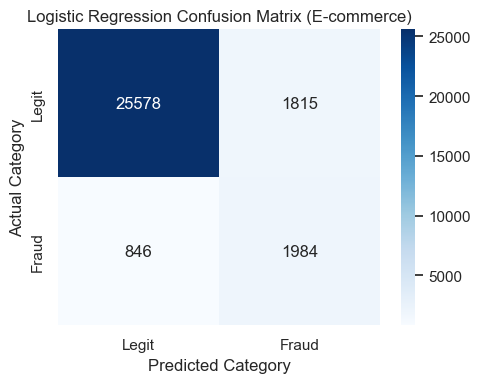


=================== Random Forest on E-commerce ===================
5-Fold CV F1-Score: 0.8755 +/- 0.0012
5-Fold CV AUC-PR:   0.9725 +/- 0.0006

--- Test Set Performance ---
Test F1-Score: 0.6267
Test AUC-PR:   0.7081

Confusion Matrix:
 [[26103  1290]
 [  950  1880]]


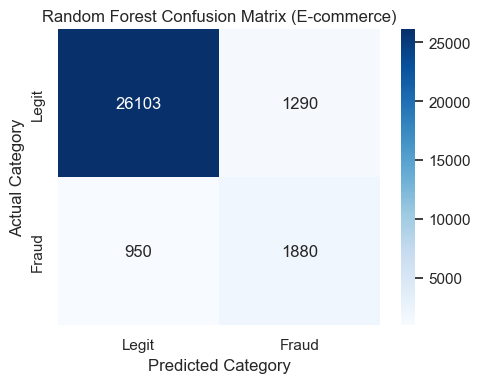

['../models/ecommerce_best_rf_model.pkl']

In [4]:
# Ingest processed E-commerce datasets
X_train_eco = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_X_train.csv"))
y_train_eco = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_y_train.csv")).iloc[:, 0]
X_test_eco = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_X_test.csv"))
y_test_eco = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_y_test.csv")).iloc[:, 0]

# Define configurations
lr_base = LogisticRegression(max_iter=1000, random_state=42)
rf_ensemble = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

# Run evaluations
results = []
results.append(evaluate_model_performance(lr_base, X_train_eco, y_train_eco, X_test_eco, y_test_eco, "E-commerce", "Logistic Regression"))
results.append(evaluate_model_performance(rf_ensemble, X_train_eco, y_train_eco, X_test_eco, y_test_eco, "E-commerce", "Random Forest"))

# Save the best model artifact
joblib.dump(rf_ensemble, os.path.join(MODELS_DIR, "ecommerce_best_rf_model.pkl"))


=================== Logistic Regression on Bank Card ===================
5-Fold CV F1-Score: 0.9513 +/- 0.0002
5-Fold CV AUC-PR:   0.9925 +/- 0.0001

--- Test Set Performance ---
Test F1-Score: 0.1094
Test AUC-PR:   0.7703

Confusion Matrix:
 [[55406  1458]
 [    8    90]]


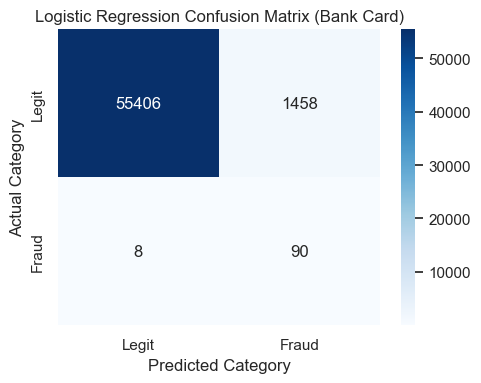


=================== Random Forest on Bank Card ===================
5-Fold CV F1-Score: 0.9995 +/- 0.0001
5-Fold CV AUC-PR:   1.0000 +/- 0.0000


In [ ]:
# Ingest processed Bank datasets
X_train_bank = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "bank_X_train.csv"))
y_train_bank = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "bank_y_train.csv")).iloc[:, 0]
X_test_bank = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "bank_X_test.csv"))
y_test_bank = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "bank_y_test.csv")).iloc[:, 0]

# Define architectures
lr_bank = LogisticRegression(max_iter=1000, random_state=42)
rf_bank = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Run evaluations
results.append(evaluate_model_performance(lr_bank, X_train_bank, y_train_bank, X_test_bank, y_test_bank, "Bank Card", "Logistic Regression"))
results.append(evaluate_model_performance(rf_bank, X_train_bank, y_train_bank, X_test_bank, y_test_bank, "Bank Card", "Random Forest"))

# Save the best model artifact
joblib.dump(rf_bank, os.path.join(MODELS_DIR, "bank_best_rf_model.pkl"))

In [1]:
# Generate a comparative summary table side-by-side
df_metrics = pd.DataFrame(results)
print("\n--- Consolidated Model Comparison Matrix ---")
print(df_metrics.to_string(index=False))

# Export matrix results out to file system
df_metrics.to_csv(os.path.join(PROCESSED_DATA_DIR, "model_comparison_matrix.csv"), index=False)

NameError: name 'pd' is not defined